# Loading the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import time
import scipy
import sklearn
import xgboost
from scipy.stats import t
from sklearn.model_selection import train_test_split
from sklearn import feature_selection
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy.stats import wilcoxon, ttest_rel, norm
%matplotlib inline

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.16.3
scikit-learn: 1.6.1
xgboost: 3.3.0


In [2]:
# Load the dataset
nbadf = pd.read_csv('/content/NBA_Revised_Dataset.csv')
mip = pd.read_csv('/content/NBA_GroundTruth_MIP.csv')

In [3]:
nbadf.head()

,Rk,Player,Age,Team,Pos,G,GS,MPAVG,FG,FGA,...,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,SEASON
0,1,Quincy Acy,25,SAC,PF,59,29,14.8,2.0,3.6,...,13.1,1.8,0.7,2.5,0.137,-0.2,0.2,-0.1,0.4,2015
1,2,Jordan Adams,21,MEM,SG,2,0,7.5,1.0,3.0,...,30.5,0.0,0.0,0.0,0.015,-2.5,9.4,6.9,0.0,2015
2,3,Steven Adams,22,OKC,C,80,80,25.2,3.3,5.3,...,12.6,4.2,2.3,6.5,0.155,0.0,0.2,0.2,1.1,2015
3,4,Arron Afflalo,30,NYK,SG,71,57,33.4,5.0,11.3,...,17.9,1.8,0.9,2.7,0.055,-1.3,-1.6,-2.9,-0.5,2015
4,5,Alexis Ajinça,27,NOP,C,59,17,14.6,2.5,5.3,...,20.4,0.2,0.9,1.0,0.058,-3.4,-0.6,-4.0,-0.4,2015


In [4]:
nbadf.shape

(5968, 53)

# Handling Missing Values

In [5]:
# Cleaning Function that shows the number and percentage of missing values within every column within the dataset
def missingValueCount(df):
  columns = df.columns
  total_rows = len(df)
  missing_data_info = {}
  for c in columns:
    missing_value_count = df[c].isnull().sum()
    if total_rows > 0:
      ratio = round(missing_value_count / total_rows, 3)
    else:
      ratio = 0.0
    missing_data_info[c] = f"Total missing value: {missing_value_count};  % of Missing Value: {ratio}"
  return missing_data_info

In [6]:
missingValueCount(nbadf)

{'Rk': 'Total missing value: 0;  % of Missing Value: 0.0',
 'Player': 'Total missing value: 0;  % of Missing Value: 0.0',
 'Age': 'Total missing value: 0;  % of Missing Value: 0.0',
 'Team': 'Total missing value: 0;  % of Missing Value: 0.0',
 'Pos': 'Total missing value: 0;  % of Missing Value: 0.0',
 'G': 'Total missing value: 0;  % of Missing Value: 0.0',
 'GS': 'Total missing value: 0;  % of Missing Value: 0.0',
 'MPAVG': 'Total missing value: 0;  % of Missing Value: 0.0',
 'FG': 'Total missing value: 0;  % of Missing Value: 0.0',
 'FGA': 'Total missing value: 0;  % of Missing Value: 0.0',
 'FG%': 'Total missing value: 30;  % of Missing Value: 0.005',
 '3P': 'Total missing value: 0;  % of Missing Value: 0.0',
 '3PA': 'Total missing value: 0;  % of Missing Value: 0.0',
 '3P%': 'Total missing value: 365;  % of Missing Value: 0.061',
 '2P': 'Total missing value: 0;  % of Missing Value: 0.0',
 '2PA': 'Total missing value: 0;  % of Missing Value: 0.0',
 '2P%': 'Total missing value: 73; 

In [7]:
# Replacing these columns with value of zero due to these players never attempting any shots from these fields
nbadf1 = nbadf.fillna({'FG%': 0.0, '3P%': 0.0, '2P%': 0.0, 'eFG%': 0.0, 'FT%': 0.0, 'TS%': 0.0, '3PAr': 0.0, 'FTr': 0.0, 'TOV%': 0})

In [8]:
# Dropping the column due to majority of values being missing
nbadf2 = nbadf1.drop(columns=['Awards'])

In [9]:
missingValueCount(nbadf2)

{'Rk': 'Total missing value: 0;  % of Missing Value: 0.0',
 'Player': 'Total missing value: 0;  % of Missing Value: 0.0',
 'Age': 'Total missing value: 0;  % of Missing Value: 0.0',
 'Team': 'Total missing value: 0;  % of Missing Value: 0.0',
 'Pos': 'Total missing value: 0;  % of Missing Value: 0.0',
 'G': 'Total missing value: 0;  % of Missing Value: 0.0',
 'GS': 'Total missing value: 0;  % of Missing Value: 0.0',
 'MPAVG': 'Total missing value: 0;  % of Missing Value: 0.0',
 'FG': 'Total missing value: 0;  % of Missing Value: 0.0',
 'FGA': 'Total missing value: 0;  % of Missing Value: 0.0',
 'FG%': 'Total missing value: 0;  % of Missing Value: 0.0',
 '3P': 'Total missing value: 0;  % of Missing Value: 0.0',
 '3PA': 'Total missing value: 0;  % of Missing Value: 0.0',
 '3P%': 'Total missing value: 0;  % of Missing Value: 0.0',
 '2P': 'Total missing value: 0;  % of Missing Value: 0.0',
 '2PA': 'Total missing value: 0;  % of Missing Value: 0.0',
 '2P%': 'Total missing value: 0;  % of Mi

# Creation of Target Variable

In [10]:
# Shift() lets us get each players next SEASON (year) stats to be in the same row in order to create the desired target variable
nbadf3 = nbadf2.sort_values(["Player", "SEASON"])
nbadf3["next_PTS"] = nbadf3.groupby("Player")["PTS"].shift(-1)
nbadf3["next_WS"] = nbadf3.groupby("Player")["WS"].shift(-1)

In [11]:
nbadf3.head()

,Rk,Player,Age,Team,Pos,G,GS,MPAVG,FG,FGA,...,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,SEASON,next_PTS,next_WS
3879,174,A.J. Green,23,MIL,SG,35,1,9.9,1.5,3.6,...,0.3,0.8,0.111,-0.3,-0.6,-0.9,0.1,2022,4.5,1.1
4427,183,A.J. Green,24,MIL,SG,56,0,11.0,1.5,3.5,...,0.3,1.1,0.084,-0.4,-1.7,-2.1,0.0,2023,7.4,2.8
4999,183,A.J. Green,25,MIL,SG,73,7,22.7,2.5,5.8,...,1.3,2.8,0.082,-1.7,-0.4,-2.2,-0.1,2024,10.4,2.4
5567,182,A.J. Green,26,MIL,SG,78,68,29.1,3.4,7.9,...,0.4,2.4,0.050,-1.5,-1.8,-3.3,-0.8,2025,NaN,NaN
646,171,A.J. Hammons,24,DAL,C,22,0,7.4,0.8,1.9,...,0.2,0.0,-0.001,-6.6,0.0,-6.6,-0.2,2016,NaN,NaN


In [12]:
# Viewing number of rows that do not have a next SEASON (year) to reference
nbadf3[nbadf3["next_PTS"].isna()][["Player", "SEASON", "PTS", "next_PTS"]]

,Player,SEASON,PTS,next_PTS
5567,A.J. Green,2025,10.4,NaN
646,A.J. Hammons,2016,2.2,NaN
5686,A.J. Lawson,2025,4.2,NaN
4434,AJ Griffin,2023,2.4,NaN
5638,AJ Johnson,2025,3.3,NaN
...,...,...,...,...
5951,te Williams,2025,8.0,NaN
5818,z Reid,2025,13.6,NaN
1502,Álex Abrines,2018,5.3,NaN
1633,Ángel Delgado,2018,1.5,NaN


In [13]:
# Removing these rows
nbadf4 = nbadf3.dropna(subset=["next_PTS", "next_WS"])

In [14]:
nbadf4['Player'].count()

np.int64(4397)

In [15]:
nbadf3['Player'].nunique()

1571

In [16]:
nbadf4['Player'].nunique()

1162

In [17]:
# Verifying that the correct number of unqiue players/rows of data were dropped from the dataset
nbadf3.groupby('Player').filter(lambda x: len(x) == 1)

,Rk,Player,Age,Team,Pos,G,GS,MPAVG,FG,FGA,...,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,SEASON,next_PTS,next_WS
646,171,A.J. Hammons,24,DAL,C,22,0,7.4,0.8,1.9,...,0.2,0.0,-0.001,-6.6,0.0,-6.6,-0.2,2016,NaN,NaN
3333,233,Aaron Henry,22,PHI,SF,6,0,2.8,0.2,0.8,...,0.0,-0.1,-0.306,-14.0,-2.4,-16.5,-0.1,2021,NaN,NaN
1205,244,Aaron Jackson,31,HOU,PG,1,0,35.0,3.0,9.0,...,0.0,0.0,-0.017,-6.6,-2.3,-8.9,-0.1,2017,NaN,NaN
5405,20,Ace Bailey,19,UTA,SF,72,61,27.6,5.5,12.4,...,0.3,-0.1,-0.001,-1.9,-2.5,-4.4,-1.2,2025,NaN,NaN
5406,21,Adama-Alpha Bal,22,MEM,SG,8,1,30.1,3.5,8.5,...,0.1,0.3,0.065,-3.6,-1.8,-5.4,-0.2,2025,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4916,100,Yuri Collins,23,GSW,PG,2,0,8.0,0.5,1.5,...,0.0,0.1,0.214,-6.2,6.5,0.3,0.0,2024,NaN,NaN
3549,449,Yves Pons,22,MEM,SF,12,0,5.9,0.4,1.3,...,0.1,0.0,0.030,-4.9,-1.7,-6.6,-0.1,2021,NaN,NaN
1809,308,Zach Lofton,26,DET,SG,1,0,4.0,0.0,1.0,...,0.0,0.0,-0.447,-17.4,6.0,-11.5,0.0,2018,NaN,NaN
2401,370,Zach Norvell,22,2TM,SG,5,0,8.2,0.6,2.4,...,0.0,-0.1,-0.084,-7.1,-1.2,-8.4,-0.1,2019,NaN,NaN


In [18]:
# Creating the columns or features that will define our target variable
# With PTS or Points Per Game percentage difference was used since this column is raw accounting data
nbadf4['PTS_difference'] = (nbadf4['next_PTS'] / nbadf4['PTS']) - 1

# With WS or Win Shares since this is a calculated column this column just took the numerical difference in values rather than percentage difference
nbadf4['WS_difference'] = nbadf4['next_WS'] - nbadf4['WS']

/tmp/ipykernel_6977/824386777.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nbadf4['PTS_difference'] = (nbadf4['next_PTS'] / nbadf4['PTS']) - 1
/tmp/ipykernel_6977/824386777.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nbadf4['WS_difference'] = nbadf4['next_WS'] - nbadf4['WS']


In [19]:
nbadf4.head()

,Rk,Player,Age,Team,Pos,G,GS,MPAVG,FG,FGA,...,WS/48,OBPM,DBPM,BPM,VORP,SEASON,next_PTS,next_WS,PTS_difference,WS_difference
3879,174,A.J. Green,23,MIL,SG,35,1,9.9,1.5,3.6,...,0.111,-0.3,-0.6,-0.9,0.1,2022,4.5,1.1,0.022727,0.3
4427,183,A.J. Green,24,MIL,SG,56,0,11.0,1.5,3.5,...,0.084,-0.4,-1.7,-2.1,0.0,2023,7.4,2.8,0.644444,1.7
4999,183,A.J. Green,25,MIL,SG,73,7,22.7,2.5,5.8,...,0.082,-1.7,-0.4,-2.2,-0.1,2024,10.4,2.4,0.405405,-0.4
3989,284,A.J. Lawson,22,2TM,SG,15,0,7.2,1.5,2.9,...,0.063,-1.5,-2.9,-4.4,-0.1,2022,3.2,0.2,-0.135135,0.1
4534,290,A.J. Lawson,23,DAL,SG,42,0,7.4,1.3,2.9,...,0.036,-3.1,-1.5,-4.6,-0.2,2023,9.1,0.8,1.843750,0.6


In [20]:
mip.head()

,pct_change_pts,change_ws
0,0.235897,5.1
1,0.858333,-1.2
2,1.043011,4.0
3,0.603053,-2.3
4,0.074510,1.9


In [21]:
ppg = mip["pct_change_pts"]

n = len(ppg)
mean = ppg.mean()
std = ppg.std(ddof=1)

margin = t.ppf(0.975, df=n-1) * (std / np.sqrt(n))
lower = mean - margin
upper = mean + margin

print(f"Mean: {mean:.2f}%")
print(f"95% CI: ({lower:.2f}%, {upper:.2f}%)")

Mean: 0.62%
95% CI: (0.46%, 0.77%)


In [22]:
ws = mip["change_ws"]

n = len(ws)
mean = ws.mean()
std = ws.std(ddof=1)

margin = t.ppf(0.975, df=n-1) * (std / np.sqrt(n))

lower = mean - margin
upper = mean + margin

print(f"Mean WS Increase: {mean:.2f}")
print(f"95% CI: ({lower:.2f}, {upper:.2f})")

Mean WS Increase: 2.62
95% CI: (1.77, 3.48)


In [23]:
# Binary Target Variable is created with the condition that a player fufills both conditions for the breakout column to equal one, otherwise the value is set as zero
nbadf4['breakout'] = ((nbadf4['PTS_difference'] >= 0.20) & (nbadf4['WS_difference'] >= 2.0)).astype(int)

/tmp/ipykernel_6977/1223704688.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nbadf4['breakout'] = ((nbadf4['PTS_difference'] >= 0.20) & (nbadf4['WS_difference'] >= 2.0)).astype(int)


In [24]:
nbadf4.head()

,Rk,Player,Age,Team,Pos,G,GS,MPAVG,FG,FGA,...,OBPM,DBPM,BPM,VORP,SEASON,next_PTS,next_WS,PTS_difference,WS_difference,breakout
3879,174,A.J. Green,23,MIL,SG,35,1,9.9,1.5,3.6,...,-0.3,-0.6,-0.9,0.1,2022,4.5,1.1,0.022727,0.3,0
4427,183,A.J. Green,24,MIL,SG,56,0,11.0,1.5,3.5,...,-0.4,-1.7,-2.1,0.0,2023,7.4,2.8,0.644444,1.7,0
4999,183,A.J. Green,25,MIL,SG,73,7,22.7,2.5,5.8,...,-1.7,-0.4,-2.2,-0.1,2024,10.4,2.4,0.405405,-0.4,0
3989,284,A.J. Lawson,22,2TM,SG,15,0,7.2,1.5,2.9,...,-1.5,-2.9,-4.4,-0.1,2022,3.2,0.2,-0.135135,0.1,0
4534,290,A.J. Lawson,23,DAL,SG,42,0,7.4,1.3,2.9,...,-3.1,-1.5,-4.6,-0.2,2023,9.1,0.8,1.843750,0.6,0


# Data Imbalance 93/7

In [25]:
nbadf4['breakout'].value_counts()

,count
breakout,
0,4084
1,313


# Feature Engineering & Importance

In [26]:
# import time
# from sklearn.model_selection import train_test_split
# from sklearn import feature_selection
# from sklearn.dummy import DummyClassifier
# from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# from scipy.stats import wilcoxon, ttest_rel, norm

In [27]:
# RK column remove due to it not having any meaning
# Team dropped due to lack of relevance
# MPTotal was dropped since it was provided redundant information
# The next 4 columns were removed due to the fact that they were used to create the target variable
# The remaining columns were removed due to the high correlation they have with other columns/features
nbadf5 = nbadf4.drop(columns=['Rk', 'Team', 'MPTotal', 'next_PTS', 'next_WS', 'PTS_difference', 'WS_difference',
                              'FG', '3P', '2P', 'FT', 'OWS', 'DWS', 'OBPM', 'DBPM'])

In [28]:
# Encoding the player positions into numerical values
nbadf6 = pd.get_dummies(nbadf5, columns=['Pos'], drop_first=True, dtype=int)

In [29]:
nbadf6.head()

,Player,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,...,WS,WS/48,BPM,VORP,SEASON,breakout,Pos_PF,Pos_PG,Pos_SF,Pos_SG
3879,A.J. Green,23,35,1,9.9,3.6,0.424,3.0,0.419,0.6,...,0.8,0.111,-0.9,0.1,2022,0,0,0,0,1
4427,A.J. Green,24,56,0,11.0,3.5,0.423,3.0,0.408,0.5,...,1.1,0.084,-2.1,0.0,2023,0,0,0,0,1
4999,A.J. Green,25,73,7,22.7,5.8,0.429,5.0,0.427,0.8,...,2.8,0.082,-2.2,-0.1,2024,0,0,0,0,1
3989,A.J. Lawson,22,15,0,7.2,2.9,0.500,1.7,0.400,1.3,...,0.1,0.063,-4.4,-0.1,2022,0,0,0,0,1
4534,A.J. Lawson,23,42,0,7.4,2.9,0.446,1.2,0.260,1.7,...,0.2,0.036,-4.6,-0.2,2023,0,0,0,0,1


In [30]:
nbadf6 = nbadf6.sort_values('SEASON').reset_index(drop=True)
nbadf6.head()

,Player,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,...,WS,WS/48,BPM,VORP,SEASON,breakout,Pos_PF,Pos_PG,Pos_SF,Pos_SG
0,Briante Weber,23,7,4,24.1,5.6,0.359,0.7,0.000,4.9,...,0.0,0.004,-3.7,-0.1,2015,0,0,1,0,0
1,Brian Roberts,30,51,0,9.2,3.2,0.448,0.8,0.357,2.4,...,1.0,0.105,-1.6,0.0,2015,0,0,1,0,0
2,Joffrey Lauvergne,24,59,15,17.6,6.4,0.513,0.9,0.245,5.5,...,2.3,0.105,-1.6,0.1,2015,0,0,0,0,0
3,Mario Hezonja,20,79,9,17.9,5.3,0.433,2.4,0.349,2.9,...,0.9,0.029,-3.1,-0.4,2015,0,0,0,1,0
4,Marcus Morris,26,80,80,35.7,11.8,0.434,3.7,0.362,8.1,...,5.4,0.091,-0.2,1.3,2015,0,0,0,1,0


In [31]:
seasons = nbadf6['SEASON']
y = nbadf6['breakout']
X = nbadf6.drop(columns=['Player', 'SEASON', 'breakout'])
X.head()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,TOV%,USG%,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG
0,23,7,4,24.1,5.6,0.359,0.7,0.000,4.9,0.412,...,18.1,13.2,0.0,0.004,-3.7,-0.1,0,1,0,0
1,30,51,0,9.2,3.2,0.448,0.8,0.357,2.4,0.480,...,11.0,19.8,1.0,0.105,-1.6,0.0,0,1,0,0
2,24,59,15,17.6,6.4,0.513,0.9,0.245,5.5,0.557,...,11.6,19.5,2.3,0.105,-1.6,0.1,0,0,0,0
3,20,79,9,17.9,5.3,0.433,2.4,0.349,2.9,0.504,...,18.0,16.9,0.9,0.029,-3.1,-0.4,0,0,1,0
4,26,80,80,35.7,11.8,0.434,3.7,0.362,8.1,0.467,...,11.6,18.4,5.4,0.091,-0.2,1.3,0,0,1,0


In [32]:
seasons.unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [33]:
final_test_season = seasons.max()
train_mask = seasons < final_test_season
test_mask = seasons == final_test_season

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]
X_test = X.loc[test_mask]
y_test = y.loc[test_mask]
season_train = seasons.loc[train_mask]

In [34]:
from sklearn.model_selection import PredefinedSplit
unique_seasons = sorted(season_train.unique())
unique_seasons

[np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023)]

# All Project Models Testing/Tunning/Evaluation

Scikit learn LogisticRegression() documentation:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Scikit learn StratifiedKFold() documentation:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html

Scikit learn cross_validate() documentation:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html

# Evaluation Metric Formulas
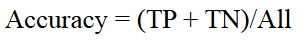
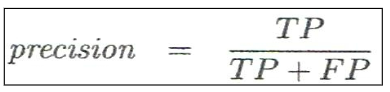
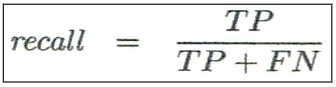
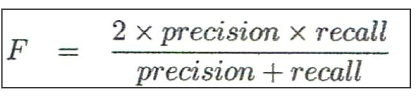

# Naive Majority Classification Baseline Model

In [35]:
results1 = []

for test_season in unique_seasons[4:]:
    train_idx = season_train < test_season
    valid_idx = season_train == test_season

    X_tr = X_train.loc[train_idx]
    y_tr = y_train.loc[train_idx]
    X_val = X_train.loc[valid_idx]
    y_val = y_train.loc[valid_idx]

    model1 = DummyClassifier(strategy = 'most_frequent')
    model1.fit(X_tr, y_tr)
    pred = model1.predict(X_val)
    prob = model1.predict_proba(X_val)[:,1]

    results1.append({
        "Season": test_season,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
    })

In [36]:
cv_results1 = pd.DataFrame(results1)
cv_results1

,Season,Accuracy,Precision,Recall,F1
0,2019,0.940265,0.0,0.0,0.0
1,2020,0.917548,0.0,0.0,0.0
2,2021,0.920530,0.0,0.0,0.0
3,2022,0.948276,0.0,0.0,0.0
4,2023,0.954649,0.0,0.0,0.0


In [37]:
cv_results1.mean(numeric_only=True)

,0
Season,2021.000000
Accuracy,0.936253
Precision,0.000000
Recall,0.000000
F1,0.000000


In [38]:
cv_results1.var(numeric_only=True)

,0
Season,2.500000
Accuracy,0.000274
Precision,0.000000
Recall,0.000000
F1,0.000000


In [39]:
start_train = time.perf_counter()
model1.fit(X_train, y_train)
end_train = time.perf_counter()
train_time = end_train - start_train
test_train = time.perf_counter()
y_pred_maj = model1.predict(X_test)
test_test = time.perf_counter()
test_time = test_test - test_train

maj_accuracy = accuracy_score(y_test, y_pred_maj)
maj_precision = precision_score(y_test, y_pred_maj, zero_division=0)
maj_recall = recall_score(y_test, y_pred_maj)
maj_f1 = f1_score(y_test, y_pred_maj)
maj_confmatrix = confusion_matrix(y_test, y_pred_maj)
maj_classification = classification_report(y_test, y_pred_maj, zero_division=0)

print(f"Training Time: {train_time:.6f} seconds")
print(f"Testing Time : {test_time:.6f} seconds")

Training Time: 0.001309 seconds
Testing Time : 0.000318 seconds


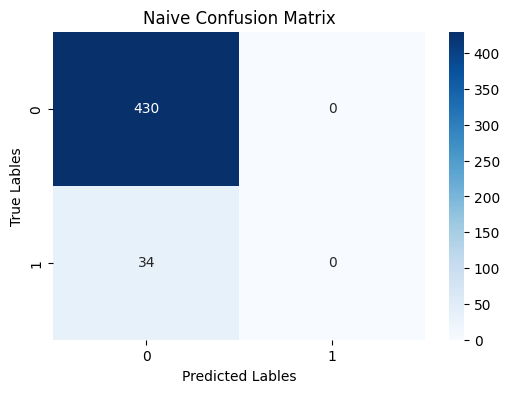

In [40]:
plt.figure(figsize=(6, 4))
sns.heatmap(maj_confmatrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Lables')
plt.ylabel('True Lables')
plt.title(f'Naive Confusion Matrix')
plt.show()

In [41]:
print(f'Accuracy: {maj_accuracy:.3f}')
print(f'Precision: {maj_precision:.3f}')
print(f'Recall: {maj_recall:.3f}')
print(f'F1 Score: {maj_f1:.3f}')
print('Classification Report:\n', maj_classification)

Accuracy: 0.927
Precision: 0.000
Recall: 0.000
F1 Score: 0.000
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       430
           1       0.00      0.00      0.00        34

    accuracy                           0.93       464
   macro avg       0.46      0.50      0.48       464
weighted avg       0.86      0.93      0.89       464



# Logistic Regression Default/Baseline Model

In [42]:
results2 = []
baseline_scores = []

for test_season in unique_seasons[4:]:
    train_idx = season_train < test_season
    valid_idx = season_train == test_season

    X_tr = X_train.loc[train_idx]
    y_tr = y_train.loc[train_idx]
    X_val = X_train.loc[valid_idx]
    y_val = y_train.loc[valid_idx]

    model2 = LogisticRegression(class_weight="balanced", max_iter=10000, random_state=42)
    model2.fit(X_tr, y_tr)
    pred = model2.predict(X_val)
    prob = model2.predict_proba(X_val)[:,1]

    baseline_scores.append(f1_score(y_val, pred, zero_division=0))
    results2.append({
        "Season": test_season,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
    })

In [43]:
cv_results2 = pd.DataFrame(results2)
cv_results2

,Season,Accuracy,Precision,Recall,F1
0,2019,0.592920,0.089005,0.629630,0.155963
1,2020,0.638478,0.137363,0.641026,0.226244
2,2021,0.624724,0.119318,0.583333,0.198113
3,2022,0.592672,0.072539,0.583333,0.129032
4,2023,0.585034,0.064171,0.600000,0.115942


In [44]:
cv_results2.mean(numeric_only=True)

,0
Season,2021.000000
Accuracy,0.606766
Precision,0.096479
Recall,0.607464
F1,0.165059


In [45]:
cv_results2.var(numeric_only=True)

,0
Season,2.500000
Accuracy,0.000548
Precision,0.000966
Recall,0.000709
F1,0.002157


In [46]:
start_train = time.perf_counter()
model2.fit(X_train, y_train)
end_train = time.perf_counter()
train_time = end_train - start_train
test_train = time.perf_counter()
y_pred_base= model2.predict(X_test)
test_test = time.perf_counter()
test_time = test_test - test_train

correct_base = y_pred_base == y_test

base_accuracy = accuracy_score(y_test, y_pred_base)
base_precision = precision_score(y_test, y_pred_base)
base_recall = recall_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base)
base_confmatrix = confusion_matrix(y_test, y_pred_base)
base_classification = classification_report(y_test, y_pred_base, zero_division=0)

print(f"Training Time: {train_time:.6f} seconds")
print(f"Testing Time : {test_time:.6f} seconds")

Training Time: 4.991735 seconds
Testing Time : 0.002704 seconds


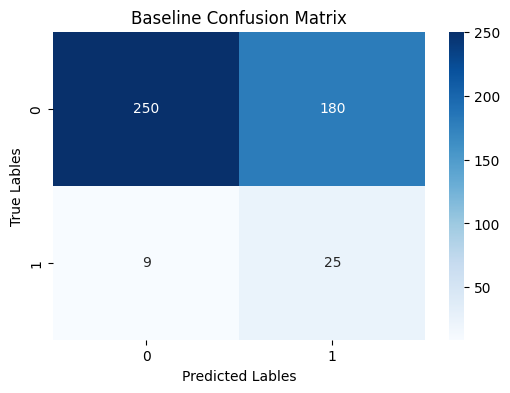

In [47]:
plt.figure(figsize=(6, 4))
sns.heatmap(base_confmatrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Lables')
plt.ylabel('True Lables')
plt.title(f'Baseline Confusion Matrix')
plt.show()

In [48]:
print(f'Accuracy: {base_accuracy:.3f}')
print(f'Precision: {base_precision:.3f}')
print(f'Recall: {base_recall:.3f}')
print(f'F1 Score: {base_f1:.3f}')
print('Classification Report:\n', base_classification)

Accuracy: 0.593
Precision: 0.122
Recall: 0.735
F1 Score: 0.209
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.58      0.73       430
           1       0.12      0.74      0.21        34

    accuracy                           0.59       464
   macro avg       0.54      0.66      0.47       464
weighted avg       0.90      0.59      0.69       464



# Parameter Tunned Logistic Regression Model

In [49]:
results3 = []
log_scores = []

for test_season in unique_seasons[4:]:
    train_idx = season_train < test_season
    valid_idx = season_train == test_season

    X_tr = X_train.loc[train_idx]
    y_tr = y_train.loc[train_idx]
    X_val = X_train.loc[valid_idx]
    y_val = y_train.loc[valid_idx]

    model3 = LogisticRegression(
        penalty="elasticnet",
        l1_ratio=0.25,
        solver="saga",
        C=0.10,
        class_weight="balanced",
        max_iter=10000,
        random_state=42
    )

    model3.fit(X_tr, y_tr)
    pred = model3.predict(X_val)
    prob = model3.predict_proba(X_val)[:,1]

    log_scores.append(f1_score(y_val, pred, zero_division=0))
    results3.append({
        "Season": test_season,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
    })

In [50]:
cv_results3 = pd.DataFrame(results3)
cv_results3

,Season,Accuracy,Precision,Recall,F1
0,2019,0.566372,0.079602,0.592593,0.140351
1,2020,0.606765,0.126904,0.641026,0.211864
2,2021,0.622517,0.127072,0.638889,0.211982
3,2022,0.601293,0.078534,0.625000,0.139535
4,2023,0.578231,0.058511,0.550000,0.105769


In [51]:
cv_results3.mean(numeric_only=True)

,0
Season,2021.000000
Accuracy,0.595036
Precision,0.094124
Recall,0.609501
F1,0.161900


In [52]:
cv_results3.var(numeric_only=True)

,0
Season,2.500000
Accuracy,0.000509
Precision,0.000971
Recall,0.001481
F1,0.002280


In [53]:
start_train = time.perf_counter()
model3.fit(X_train, y_train)
end_train = time.perf_counter()
train_time = end_train - start_train
test_train = time.perf_counter()
y_pred_tune = model3.predict(X_test)
test_test = time.perf_counter()
test_time = test_test - test_train

correct_log = y_pred_tune == y_test

tune_accuracy = accuracy_score(y_test, y_pred_tune)
tune_precision = precision_score(y_test, y_pred_tune)
tune_recall = recall_score(y_test, y_pred_tune)
tune_f1 = f1_score(y_test, y_pred_tune)
tune_confmatrix = confusion_matrix(y_test, y_pred_tune)
tune_classification = classification_report(y_test, y_pred_tune, zero_division=0)

print(f"Training Time: {train_time:.6f} seconds")
print(f"Testing Time : {test_time:.6f} seconds")

Training Time: 18.808745 seconds
Testing Time : 0.002420 seconds


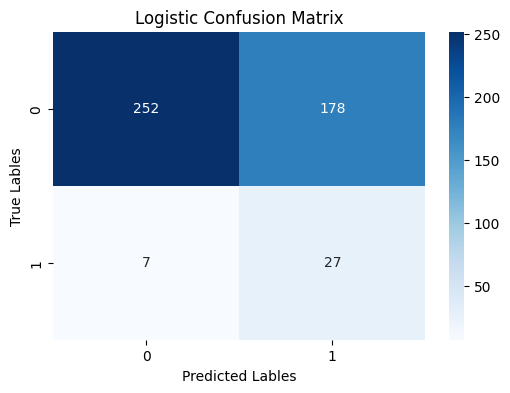

In [54]:
plt.figure(figsize=(6, 4))
sns.heatmap(tune_confmatrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Lables')
plt.ylabel('True Lables')
plt.title(f'Logistic Confusion Matrix')
plt.show()

In [55]:
print(f'Accuracy: {tune_accuracy:.3f}')
print(f'Precision: {tune_precision:.3f}')
print(f'Recall: {tune_recall:.3f}')
print(f'F1 Score: {tune_f1:.3f}')
print('Classification Report:\n', tune_classification)

Accuracy: 0.601
Precision: 0.132
Recall: 0.794
F1 Score: 0.226
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.59      0.73       430
           1       0.13      0.79      0.23        34

    accuracy                           0.60       464
   macro avg       0.55      0.69      0.48       464
weighted avg       0.91      0.60      0.69       464



# Parameter Tunned XGBoost Model

In [56]:
results4 = []
train_sizes = []
xgb_tscores = []
xgb_scores = []

for test_season in unique_seasons[4:]:
    train_idx = season_train < test_season
    valid_idx = season_train == test_season

    X_tr = X_train.loc[train_idx]
    y_tr = y_train.loc[train_idx]
    X_val = X_train.loc[valid_idx]
    y_val = y_train.loc[valid_idx]

    negative = (y_tr == 0).sum()
    positive = (y_tr == 1).sum()
    scale = negative / positive

    model4 = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale,
        n_estimators=50,
        max_depth=7,
        learning_rate=0.01,
        random_state=42
    )

    model4.fit(X_tr, y_tr)
    train_pred = model4.predict(X_tr)
    pred = model4.predict(X_val)
    prob = model4.predict_proba(X_val)[:,1]

    train_sizes.append(len(X_tr))
    xgb_tscores.append(f1_score(y_tr, train_pred, zero_division=0))
    xgb_scores.append(f1_score(y_val, pred, zero_division=0))
    results4.append({
        "Season": test_season,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
    })

In [57]:
cv_results4 = pd.DataFrame(results4)
cv_results4

,Season,Accuracy,Precision,Recall,F1
0,2019,0.663717,0.050360,0.259259,0.084337
1,2020,0.649049,0.119760,0.512821,0.194175
2,2021,0.655629,0.110390,0.472222,0.178947
3,2022,0.715517,0.071429,0.375000,0.120000
4,2023,0.689342,0.072993,0.500000,0.127389


In [58]:
cv_results4.mean(numeric_only=True)

,0
Season,2021.000000
Accuracy,0.674651
Precision,0.084986
Recall,0.423860
F1,0.140970


In [59]:
cv_results4.var(numeric_only=True)

,0
Season,2.500000
Accuracy,0.000756
Precision,0.000845
Recall,0.011383
F1,0.002026


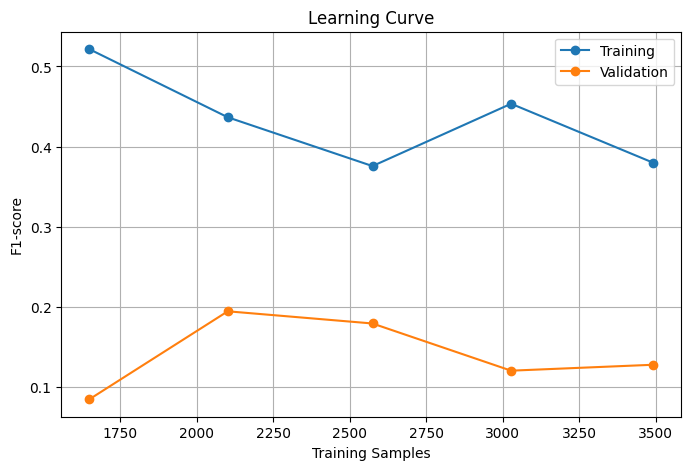

In [60]:
plt.figure(figsize=(8,5))
plt.plot(train_sizes, xgb_tscores, marker='o', label="Training")
plt.plot(train_sizes, xgb_scores, marker='o', label="Validation")

plt.xlabel("Training Samples")
plt.ylabel("F1-score")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
start_train = time.perf_counter()
model4.fit(X_train, y_train)
end_train = time.perf_counter()
train_time = end_train - start_train
test_train = time.perf_counter()
y_pred_xgb= model4.predict(X_test)
test_test = time.perf_counter()
test_time = test_test - test_train

correct_xgb = y_pred_xgb == y_test

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_confmatrix = confusion_matrix(y_test, y_pred_xgb)
xgb_classification = classification_report(y_test, y_pred_xgb, zero_division=0)

print(f"Training Time: {train_time:.6f} seconds")
print(f"Testing Time : {test_time:.6f} seconds")

Training Time: 0.563161 seconds
Testing Time : 0.006591 seconds


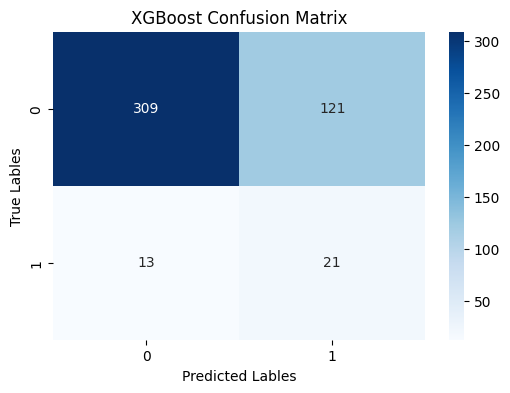

In [62]:
plt.figure(figsize=(6, 4))
sns.heatmap(xgb_confmatrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Lables')
plt.ylabel('True Lables')
plt.title(f'XGBoost Confusion Matrix')
plt.show()

In [63]:
print(f'Accuracy: {xgb_accuracy:.3f}')
print(f'Precision: {xgb_precision:.3f}')
print(f'Recall: {xgb_recall:.3f}')
print(f'F1 Score: {xgb_f1:.3f}')
print('Classification Report:\n', xgb_classification)

Accuracy: 0.711
Precision: 0.148
Recall: 0.618
F1 Score: 0.239
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.72      0.82       430
           1       0.15      0.62      0.24        34

    accuracy                           0.71       464
   macro avg       0.55      0.67      0.53       464
weighted avg       0.90      0.71      0.78       464



## Model Results Comparison

| Comparison | Accuracy | Precision | Recall | F1-score |
|------------|----------|-----------|--------|----------|
| Naive Majority | 0.927 | 0.000 | 0.000 | 0.000 |
| Baseline Logistic | 0.593 | 0.122 | 0.735 | 0.209 |
| Tunned Logistic | 0.601 | 0.132 | 0.794 | 0.226 |
| Tunned XGBoost | 0.711 | 0.148 | 0.618 | 0.239 |

# Error Analysis

Tunned Logistic Regression

In [64]:
misclassified = X_test[y_test != y_pred_tune].copy()
misclassified["Actual"] = y_test[y_test != y_pred_tune]
misclassified["Predicted"] = y_pred_tune[y_test != y_pred_tune]

print(f"Number of misclassified examples: {len(misclassified)}")
misclassified.head()

Number of misclassified examples: 185


,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
3937,24,5,1,12.6,6.4,0.406,2.0,0.200,4.4,0.500,...,0.1,0.093,-5.5,-0.1,1,0,0,0,0,1
3938,25,40,0,6.8,1.8,0.458,0.7,0.231,1.2,0.587,...,0.5,0.085,-2.1,0.0,1,0,0,0,0,1
3940,23,6,5,27.0,7.2,0.419,3.5,0.381,3.7,0.455,...,0.3,0.095,-0.6,0.1,0,1,0,0,0,1
3942,22,66,55,21.5,6.6,0.580,0.8,0.346,5.8,0.612,...,4.9,0.165,-0.1,0.7,0,0,0,0,0,1
3946,24,57,4,10.7,2.5,0.496,0.9,0.327,1.6,0.596,...,1.2,0.097,-1.3,0.1,1,0,0,0,0,1


In [65]:
false_positives = misclassified[(misclassified["Actual"] == 0) & (misclassified["Predicted"] == 1)]
false_positives.head()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
3937,24,5,1,12.6,6.4,0.406,2.0,0.200,4.4,0.500,...,0.1,0.093,-5.5,-0.1,1,0,0,0,0,1
3938,25,40,0,6.8,1.8,0.458,0.7,0.231,1.2,0.587,...,0.5,0.085,-2.1,0.0,1,0,0,0,0,1
3940,23,6,5,27.0,7.2,0.419,3.5,0.381,3.7,0.455,...,0.3,0.095,-0.6,0.1,0,1,0,0,0,1
3942,22,66,55,21.5,6.6,0.580,0.8,0.346,5.8,0.612,...,4.9,0.165,-0.1,0.7,0,0,0,0,0,1
3946,24,57,4,10.7,2.5,0.496,0.9,0.327,1.6,0.596,...,1.2,0.097,-1.3,0.1,1,0,0,0,0,1


In [66]:
false_positives.describe()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
count,178.00000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,...,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.0,178.0
mean,22.88764,43.735955,11.101124,16.415730,5.641573,0.459831,2.339326,0.290556,3.300000,0.542691,...,1.165169,0.075955,-1.839326,0.060112,0.191011,0.174157,0.224719,0.185393,0.0,1.0
std,2.30420,22.566736,16.315079,7.843662,3.585101,0.102585,1.894632,0.134756,2.285721,0.109667,...,1.291878,0.075448,4.507385,0.627734,0.394207,0.380314,0.418575,0.389713,0.0,0.0
min,19.00000,1.000000,0.000000,2.500000,0.700000,0.125000,0.000000,0.000000,0.300000,0.167000,...,-1.200000,-0.081000,-14.700000,-1.600000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
25%,21.00000,26.250000,0.000000,10.325000,3.200000,0.405250,0.900000,0.257250,1.600000,0.475250,...,0.100000,0.032250,-3.700000,-0.200000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
50%,23.00000,46.000000,3.000000,16.000000,4.950000,0.444000,1.900000,0.322500,2.800000,0.531000,...,0.800000,0.071500,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
75%,24.00000,62.750000,15.750000,22.000000,7.575000,0.499000,3.500000,0.355000,4.300000,0.589500,...,1.875000,0.108000,-0.150000,0.300000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
max,31.00000,82.000000,69.000000,34.400000,19.800000,1.000000,10.900000,1.000000,13.900000,1.000000,...,5.800000,0.565000,44.100000,3.300000,1.000000,1.000000,1.000000,1.000000,0.0,1.0


In [67]:
false_negatives = misclassified[(misclassified["Actual"] == 1) & (misclassified["Predicted"] == 0)]
false_negatives.head()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
3954,31,68,19,18.5,4.2,0.429,2.1,0.326,2.1,0.527,...,1.6,0.063,-2.3,-0.1,0,0,0,1,1,0
4009,30,47,47,32.4,12.2,0.373,6.3,0.365,5.9,0.381,...,1.8,0.057,-1.6,0.1,1,0,0,0,1,0
4039,23,7,0,3.3,1.4,0.300,1.0,0.143,0.4,0.667,...,-0.1,-0.150,-15.8,-0.1,0,1,0,0,1,0
4066,29,42,3,11.9,3.6,0.533,0.6,0.423,3.0,0.556,...,1.7,0.159,0.4,0.3,0,0,0,0,1,0
4137,26,82,10,25.3,7.5,0.438,4.5,0.381,3.0,0.524,...,4.3,0.099,-0.4,0.8,0,0,0,1,1,0


In [68]:
false_negatives.describe()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.0,7.0
mean,28.142857,47.000000,20.285714,21.942857,7.928571,0.437571,3.385714,0.339571,4.542857,0.543286,...,2.185714,0.065143,-2.600000,0.371429,0.142857,0.142857,0.142857,0.428571,1.0,0.0
std,3.579040,23.776739,17.528209,11.179424,5.414399,0.080509,2.171350,0.094325,3.703538,0.088709,...,1.428786,0.102099,6.091798,0.585133,0.377964,0.377964,0.377964,0.534522,0.0,0.0
min,23.000000,7.000000,0.000000,3.300000,1.400000,0.300000,0.600000,0.143000,0.400000,0.381000,...,-0.100000,-0.150000,-15.800000,-0.100000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
25%,25.500000,39.500000,6.500000,15.200000,3.900000,0.401000,1.550000,0.327000,2.550000,0.525500,...,1.650000,0.060000,-1.950000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
50%,29.000000,46.000000,19.000000,25.300000,7.500000,0.438000,4.100000,0.365000,3.000000,0.536000,...,1.800000,0.087000,-1.600000,0.100000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
75%,30.500000,57.500000,31.500000,31.100000,11.000000,0.495000,4.800000,0.396000,5.800000,0.584000,...,3.000000,0.120000,0.000000,0.550000,0.000000,0.000000,0.000000,1.000000,1.0,0.0
max,33.000000,82.000000,47.000000,32.400000,16.800000,0.533000,6.300000,0.423000,11.700000,0.667000,...,4.300000,0.159000,3.100000,1.500000,1.000000,1.000000,1.000000,1.000000,1.0,0.0


Tunned XGBoost

In [69]:
misclassified1 = X_test[y_test != y_pred_xgb].copy()
misclassified1["Actual"] = y_test[y_test != y_pred_xgb]
misclassified1["Predicted"] = y_pred_xgb[y_test != y_pred_xgb]

print(f"Number of misclassified examples: {len(misclassified1)}")
misclassified1.head()

Number of misclassified examples: 134


,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
3936,27,69,31,27.8,10.3,0.508,3.2,0.275,7.2,0.611,...,3.5,0.087,-0.8,0.6,0,0,1,0,0,1
3938,25,40,0,6.8,1.8,0.458,0.7,0.231,1.2,0.587,...,0.5,0.085,-2.1,0.0,1,0,0,0,0,1
3942,22,66,55,21.5,6.6,0.580,0.8,0.346,5.8,0.612,...,4.9,0.165,-0.1,0.7,0,0,0,0,0,1
3944,24,42,14,16.3,6.5,0.449,4.3,0.408,2.3,0.526,...,1.7,0.116,0.1,0.4,1,0,0,0,0,1
3945,26,28,7,13.6,4.4,0.475,1.4,0.375,2.9,0.524,...,1.0,0.126,-0.3,0.2,0,1,0,0,0,1


In [70]:
false_positives = misclassified1[(misclassified1["Actual"] == 0) & (misclassified1["Predicted"] == 1)]
false_positives.head()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
3936,27,69,31,27.8,10.3,0.508,3.2,0.275,7.2,0.611,...,3.5,0.087,-0.8,0.6,0,0,1,0,0,1
3938,25,40,0,6.8,1.8,0.458,0.7,0.231,1.2,0.587,...,0.5,0.085,-2.1,0.0,1,0,0,0,0,1
3942,22,66,55,21.5,6.6,0.580,0.8,0.346,5.8,0.612,...,4.9,0.165,-0.1,0.7,0,0,0,0,0,1
3944,24,42,14,16.3,6.5,0.449,4.3,0.408,2.3,0.526,...,1.7,0.116,0.1,0.4,1,0,0,0,0,1
3945,26,28,7,13.6,4.4,0.475,1.4,0.375,2.9,0.524,...,1.0,0.126,-0.3,0.2,0,1,0,0,0,1


In [71]:
false_positives.describe()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,...,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.0,121.0
mean,23.446281,49.727273,15.991736,18.094215,6.209091,0.460901,2.284298,0.292554,3.923140,0.537421,...,1.747107,0.084331,-1.400000,0.253719,0.214876,0.148760,0.173554,0.206612,0.0,1.0
std,3.054915,17.623847,18.417155,7.536702,3.580666,0.098668,1.568280,0.110626,2.684361,0.108688,...,1.570673,0.058585,2.777829,0.681914,0.412444,0.357332,0.380300,0.406558,0.0,0.0
min,19.000000,1.000000,0.000000,3.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.400000,-0.114000,-11.800000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
25%,21.000000,36.000000,1.000000,12.400000,3.400000,0.419000,1.000000,0.274000,1.900000,0.500000,...,0.500000,0.047000,-3.000000,-0.200000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
50%,23.000000,52.000000,8.000000,18.400000,5.700000,0.457000,2.100000,0.323000,3.300000,0.534000,...,1.300000,0.081000,-1.200000,0.100000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
75%,24.000000,64.000000,27.000000,24.900000,8.000000,0.497000,3.300000,0.355000,5.100000,0.581000,...,2.500000,0.118000,0.300000,0.500000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
max,38.000000,81.000000,67.000000,33.700000,19.400000,0.722000,6.300000,0.438000,13.500000,1.000000,...,6.800000,0.232000,4.300000,2.600000,1.000000,1.000000,1.000000,1.000000,0.0,1.0


In [72]:
false_negatives = misclassified1[(misclassified1["Actual"] == 1) & (misclassified1["Predicted"] == 0)]
false_negatives.head()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
3955,26,38,10,18.6,3.6,0.422,2.6,0.316,1.0,0.703,...,0.4,0.030,-3.5,-0.3,0,0,0,0,1,0
4009,30,47,47,32.4,12.2,0.373,6.3,0.365,5.9,0.381,...,1.8,0.057,-1.6,0.1,1,0,0,0,1,0
4039,23,7,0,3.3,1.4,0.300,1.0,0.143,0.4,0.667,...,-0.1,-0.150,-15.8,-0.1,0,1,0,0,1,0
4044,23,71,8,17.5,3.9,0.596,0.1,0.000,3.9,0.609,...,3.2,0.125,-1.9,0.0,0,0,0,0,1,0
4066,29,42,3,11.9,3.6,0.533,0.6,0.423,3.0,0.556,...,1.7,0.159,0.4,0.3,0,0,0,0,1,0


In [73]:
false_negatives.describe()

,Age,G,GS,MPAVG,FGA,FG%,3PA,3P%,2PA,2P%,...,WS,WS/48,BPM,VORP,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Actual,Predicted
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,...,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.0,13.0
mean,25.076923,49.846154,17.692308,21.423077,7.100000,0.461769,2.815385,0.280000,4.276923,0.559231,...,2.261538,0.072846,-2.092308,0.407692,0.230769,0.230769,0.153846,0.153846,1.0,0.0
std,3.817974,20.272503,17.099633,9.983165,4.983305,0.094225,2.479868,0.143948,3.309369,0.088163,...,2.159683,0.081954,4.746483,1.029127,0.438529,0.438529,0.375534,0.375534,0.0,0.0
min,20.000000,7.000000,0.000000,3.300000,1.400000,0.300000,0.000000,0.000000,0.400000,0.381000,...,-0.100000,-0.150000,-15.800000,-0.300000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
25%,22.000000,38.000000,5.000000,17.100000,3.600000,0.391000,1.000000,0.273000,2.600000,0.524000,...,1.000000,0.044000,-2.700000,-0.200000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
50%,25.000000,47.000000,10.000000,18.700000,5.000000,0.438000,2.300000,0.328000,3.000000,0.556000,...,1.700000,0.084000,-1.600000,0.100000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
75%,26.000000,67.000000,35.000000,31.500000,10.100000,0.533000,4.500000,0.381000,5.900000,0.611000,...,3.200000,0.125000,-0.400000,0.300000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
max,33.000000,82.000000,47.000000,32.400000,16.800000,0.604000,7.600000,0.423000,11.700000,0.703000,...,8.000000,0.172000,4.100000,3.400000,1.000000,1.000000,1.000000,1.000000,1.0,0.0


# Statistic Signifigance Tests

In [74]:
baseline_scores = np.array(baseline_scores)
log_scores = np.array(log_scores)
xgb_scores = np.array(xgb_scores)

### Baseline Logistic Regression Against Tunned XGBoost

In [75]:
print(f"Baseline Logistic - Mean F1-score: {baseline_scores.mean():.4f} (+/- {baseline_scores.std(ddof=1):.4f})")
print(f"Tunned XGBoost - Mean F1-score: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")
print(f"\nNumber of paired scores: {len(xgb_scores)}")
print(f"Observed difference in means: {xgb_scores.mean() - baseline_scores.mean():.4f}")

Baseline Logistic - Mean F1-score: 0.1651 (+/- 0.0464)
Tunned XGBoost - Mean F1-score: 0.1410 (+/- 0.0403)

Number of paired scores: 5
Observed difference in means: -0.0241


In [76]:
t_stat, p_value_ttest = ttest_rel(xgb_scores, baseline_scores)

print("=== Paired t-test ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value_ttest:.6f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_ttest < 0.05:
    print("REJECT H0 - The difference is statistically significant.")
else:
    print("FAIL TO REJECT H0 - No significant difference detected.")

=== Paired t-test ===
t-statistic: -1.7391
p-value: 0.156995

Conclusion at alpha=0.05: FAIL TO REJECT H0 - No significant difference detected.


In [77]:
from scipy import stats
# b: xgboost correct, baseline wrong
b = np.sum(correct_xgb & ~correct_base)
# c: xgboost wrong, baseline correct
c = np.sum(~correct_xgb & correct_base)

print("=== McNemar's Test ===")
print(f"\nContingency table of disagreements:")
print(f"  XGBoost correct, Baseline wrong (b): {b}")
print(f"  XGBoost wrong, Baseline correct (c): {c}")

# McNemar's test with continuity correction
if b + c > 0:
    chi2_mcnemar = (abs(b - c) - 1)**2 / (b + c)
    p_value_mcnemar = 1 - stats.chi2.cdf(chi2_mcnemar, df=1)

    print(f"\nChi-squared statistic: {chi2_mcnemar:.4f}")
    print(f"p-value: {p_value_mcnemar:.6f}")
    print(f"\nConclusion at alpha=0.05: ", end="")
    if p_value_mcnemar < 0.05:
        print("REJECT H0 - The models have significantly different error rates.")
    else:
        print("FAIL TO REJECT H0 - No significant difference in error rates.")
else:
    print("\nBoth models made identical predictions - cannot perform McNemar's test.")

=== McNemar's Test ===

Contingency table of disagreements:
  XGBoost correct, Baseline wrong (b): 94
  XGBoost wrong, Baseline correct (c): 39

Chi-squared statistic: 21.9248
p-value: 0.000003

Conclusion at alpha=0.05: REJECT H0 - The models have significantly different error rates.


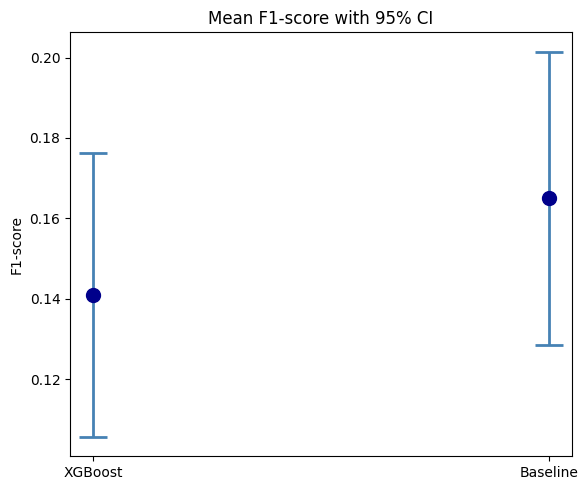

In [78]:
# CI error bar plot
plt.figure(figsize=(6, 5))
models = ['XGBoost', 'Baseline']
means = [xgb_scores.mean(), baseline_scores.mean()]
stds = [xgb_scores.std(), baseline_scores.std()]
ci_errors = [1.96 * s / np.sqrt(len(xgb_scores)) for s in stds]

plt.errorbar(models, means, yerr=ci_errors, fmt='o', capsize=10, capthick=2,
                 markersize=10, color='darkblue', ecolor='steelblue', elinewidth=2)
plt.title('Mean F1-score with 95% CI')
plt.ylabel('F1-score')
#plt.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

### Tunned Logistic Regression Against Tunned XGBoost

In [79]:
print(f"Tunned Logistic - Mean F1-score: {log_scores.mean():.4f} (+/- {log_scores.std(ddof=1):.4f})")
print(f"Tunned XGBoost - Mean F1-score: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")
print(f"\nNumber of paired scores: {len(xgb_scores)}")
print(f"Observed difference in means: {xgb_scores.mean() - log_scores.mean():.4f}")

Tunned Logistic - Mean F1-score: 0.1619 (+/- 0.0477)
Tunned XGBoost - Mean F1-score: 0.1410 (+/- 0.0403)

Number of paired scores: 5
Observed difference in means: -0.0209


In [80]:
t_stat, p_value_ttest = ttest_rel(xgb_scores, log_scores)

print("=== Paired t-test ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value_ttest:.6f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_ttest < 0.05:
    print("REJECT H0 - The difference is statistically significant.")
else:
    print("FAIL TO REJECT H0 - No significant difference detected.")

=== Paired t-test ===
t-statistic: -1.6546
p-value: 0.173340

Conclusion at alpha=0.05: FAIL TO REJECT H0 - No significant difference detected.


In [81]:
# b: xgboost correct, logistic wrong
b = np.sum(correct_xgb & ~correct_log)
# c: xgboost wrong, logistic correct
c = np.sum(~correct_xgb & correct_log)

print("=== McNemar's Test ===")
print(f"\nContingency table of disagreements:")
print(f"  XGBoost correct, Logistic wrong (b): {b}")
print(f"  XGBoost wrong, Logistic correct (c): {c}")

# McNemar's test with continuity correction
if b + c > 0:
    chi2_mcnemar = (abs(b - c) - 1)**2 / (b + c)
    p_value_mcnemar = 1 - stats.chi2.cdf(chi2_mcnemar, df=1)

    print(f"\nChi-squared statistic: {chi2_mcnemar:.4f}")
    print(f"p-value: {p_value_mcnemar:.6f}")
    print(f"\nConclusion at alpha=0.05: ", end="")
    if p_value_mcnemar < 0.05:
        print("REJECT H0 - The models have significantly different error rates.")
    else:
        print("FAIL TO REJECT H0 - No significant difference in error rates.")
else:
    print("\nBoth models made identical predictions - cannot perform McNemar's test.")

=== McNemar's Test ===

Contingency table of disagreements:
  XGBoost correct, Logistic wrong (b): 90
  XGBoost wrong, Logistic correct (c): 39

Chi-squared statistic: 19.3798
p-value: 0.000011

Conclusion at alpha=0.05: REJECT H0 - The models have significantly different error rates.


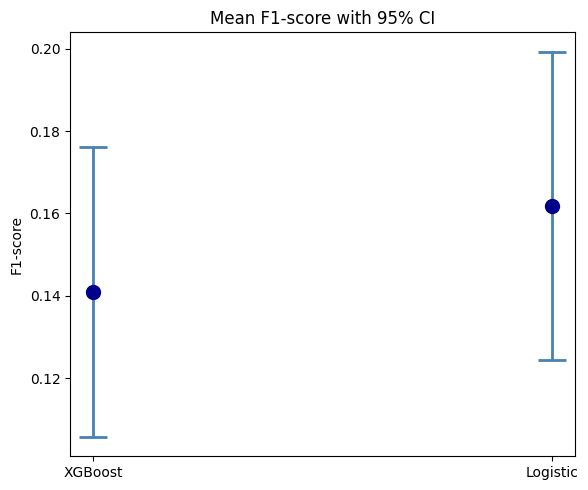

In [82]:
# CI error bar plot
plt.figure(figsize=(6, 5))
models = ['XGBoost', 'Logistic']
means = [xgb_scores.mean(), log_scores.mean()]
stds = [xgb_scores.std(), log_scores.std()]
ci_errors = [1.96 * s / np.sqrt(len(xgb_scores)) for s in stds]

plt.errorbar(models, means, yerr=ci_errors, fmt='o', capsize=10, capthick=2,
                 markersize=10, color='darkblue', ecolor='steelblue', elinewidth=2)
plt.title('Mean F1-score with 95% CI')
plt.ylabel('F1-score')
#plt.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()